# Z-score chhote dataset me SIRF ek outlier detect karega →
But usko replace nahi karega agar:
* std high hai
* mean shifted hai

In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [5]:
ds = pd.read_csv('outliee_height.csv')
ds

,NAME,HEIGHT
0,KARAN,1.2
1,JAVED,2.9
2,SOHAN,4.9
3,MAHIMA,4.8
4,JOHN,5.1
5,KRISHNA,5.4
6,KAMINI,5.2
7,GAGAN,5.8
8,RAM,5.6
9,RAVI,5.7


In [6]:
ds['HEIGHT'].describe()

count    20.000000
mean      9.300000
std       9.624147
min       1.200000
25%       5.175000
50%       5.750000
75%       6.375000
max      38.200000
Name: HEIGHT, dtype: float64

In [7]:
orignal_data = ds['HEIGHT'].copy()

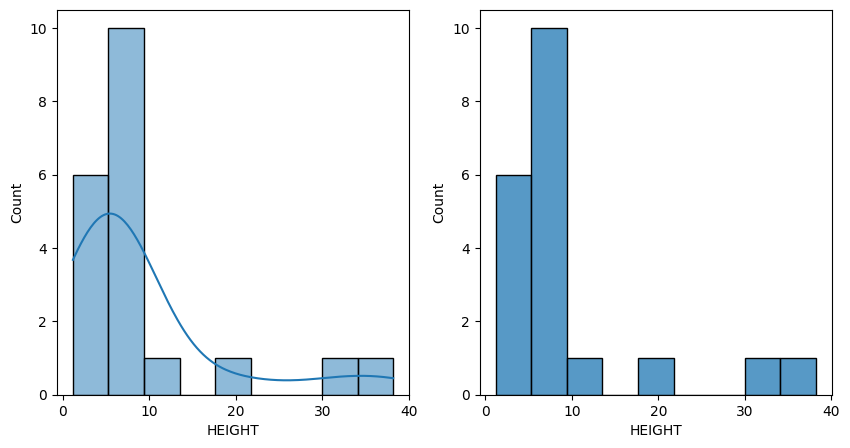

In [8]:
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
sns.histplot(ds['HEIGHT'], kde = True)
plt.subplot(1,2,2)
sns.histplot(ds['HEIGHT'])
plt.show()

In [9]:
upper_limit = ds['HEIGHT'].mean() + 3*ds['HEIGHT'].std()
lower_limit = ds['HEIGHT'].mean() - 3*ds['HEIGHT'].std()
print(upper_limit)
print(lower_limit)

38.17244178688118
-19.572441786881175


In [10]:
# detect the outliear 
ds[(ds['HEIGHT'] > upper_limit) | (ds['HEIGHT'] < lower_limit)]

,NAME,HEIGHT
19,DINESH,38.2


In [23]:
ds[(ds['HEIGHT'] < upper_limit) & (ds['HEIGHT'] > lower_limit)] 

,NAME,HEIGHT
0,KARAN,1.2
1,JAVED,2.9
2,SOHAN,4.9
3,MAHIMA,4.8
4,JOHN,5.1
5,KRISHNA,5.4
6,KAMINI,5.2
7,GAGAN,5.8
8,RAM,5.6
9,RAVI,5.7


In [20]:
ds['HEIGHT'] = np.where(ds['HEIGHT'] > upper_limit, upper_limit, np.where(ds['HEIGHT'] < lower_limit, lower_limit,ds['HEIGHT']))

In [21]:
ds['HEIGHT']

0      1.200000
1      2.900000
2      4.900000
3      4.800000
4      5.100000
5      5.400000
6      5.200000
7      5.800000
8      5.600000
9      5.700000
10     5.800000
11     6.100000
12     6.200000
13     5.600000
14     5.900000
15     6.900000
16    12.900000
17    20.300000
18    31.500000
19    38.172442
Name: HEIGHT, dtype: float64

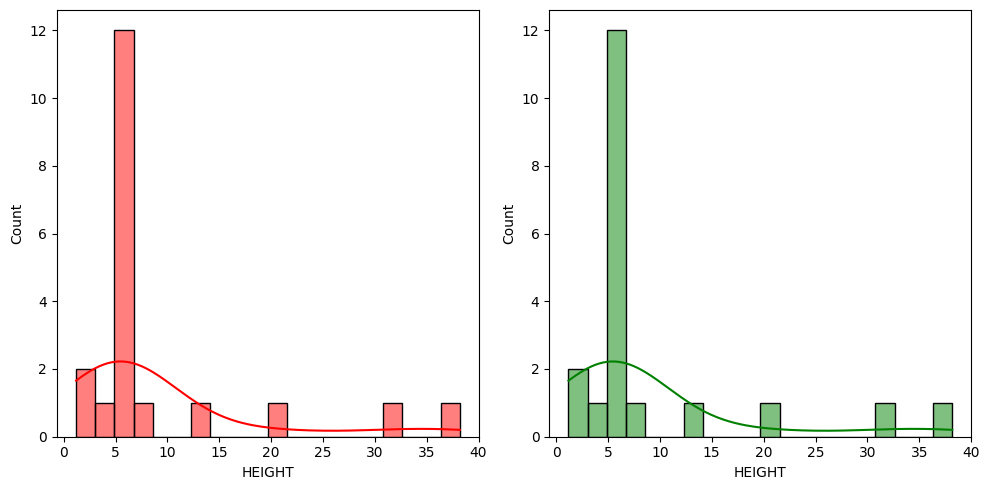

In [14]:
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
sns.histplot(orignal_data , kde = True, color= 'red', bins=20)


plt.subplot(1,2,2)
sns.histplot(ds['HEIGHT'], kde = True , color = 'green', bins = 20)
plt.tight_layout()
plt.show()

In [15]:
ds['HEIGHT'].describe()

count    20.000000
mean      9.298622
std       9.619793
min       1.200000
25%       5.175000
50%       5.750000
75%       6.375000
max      38.172442
Name: HEIGHT, dtype: float64

In [22]:
ds

,NAME,HEIGHT
0,KARAN,1.200000
1,JAVED,2.900000
2,SOHAN,4.900000
3,MAHIMA,4.800000
4,JOHN,5.100000
5,KRISHNA,5.400000
6,KAMINI,5.200000
7,GAGAN,5.800000
8,RAM,5.600000
9,RAVI,5.700000
